In [17]:
import numpy as np
# import torch 
import xarray as xr 
import dataset as ds 
import torch 
import pandas as pd 

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
data = ds.MapsDataset(
    input_path = ['/scratch/users/linyao/ML4MJO/data/fltano120/olr.fltano120.noaa.2x2.1979to2022based1979to2001.nc',],
    target_path = '/scratch/users/linyao/ML4MJO/data/targets/noaa/ROMI_NOAA_1979to2022.nc',
    date_start = '1980-01-01',
    date_end = '1980-12-31',   
    lead = 35,
    lat_range = 20, 
)

In [16]:
samples = [data[i][0] for i in range(len(data))]
samples_stack = torch.stack(samples)
print(f"Mean: {samples_stack.mean().item():.4f}")
print(f"Std: {samples_stack.std().item():.4f}")
print(f"Max: {samples_stack.max().item():.4f}")
print(f"Min: {samples_stack.min().item():.4f}")

Mean: -0.0169
Std: 0.9395
Max: 3.5392
Min: -6.2517


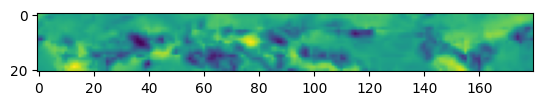

In [5]:
import matplotlib.pyplot as plt
plt.imshow(data[0][0][0, :, :], cmap='viridis')
# plt.colorbar()

In [18]:
idx = 100
img, label = data[idx]

input_time = data.input.time[idx].values
target_time_expected = pd.Timestamp(input_time) + pd.Timedelta(days=35)

actual_raw_target = xr.open_dataarray('/scratch/users/linyao/ML4MJO/data/targets/noaa/ROMI_NOAA_1979to2022.nc').sel(time=target_time_expected)

print(f"Input Time: {input_time}")
print(f"Expected Target Time (at max lead): {target_time_expected}")

n_modes = actual_raw_target.shape[0] 
dataset_last_lead_val = label.reshape(35+1, n_modes)[-1]

print(f"Raw target value: {actual_raw_target.values[:3]}...") # 取前三个 mode 比较
print(f"Dataset target value: {dataset_last_lead_val[:3]}...")

Input Time: 1980-04-10T00:00:00.000000000
Expected Target Time (at max lead): 1980-05-15 00:00:00
Raw target value: [-0.63 -0.65]...
Dataset target value: tensor([-0.6300, -0.6500])...
